# TP1 – Équation de la Chaleur 1D 

In [219]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Paramètres de Simulation

In [220]:
# --- Parametres physiques ---
L = 1.0 # Longueur de la barre (m)
alpha = 1.11e-4 # Diffusivite thermique du cuivre (m^2/s)
T_gauche = 100.0 # Temperature a x=0 ( degC )
T_droite = 0.0 # Temperature a x=L ( degC )
T_init = 0.0 # Temperature initiale uniforme ( degC )

# --- Parametres numeriques ---
N = 20 # Nombre d’intervalles spatiaux
dx = L / N # Pas spatial (m)
r = 0.4 # Nombre de Fourier discret ( choisir r <= 0.5)
dt = (r * dx**2) / alpha # Pas de temps : a calculer depuis r, dx et alpha
t_fin = 3000 # Duree de simulation (s)
nt = int ( t_fin / dt )

print ( f"dx = {dx :.4f} m")
print ( f"dt = {dt :.4f} s")
print ( f"r = {r:.4f} ( doit etre <= 0.5) ")
print ( f" Nombre de pas de temps : {nt}")

dx = 0.0500 m
dt = 9.0090 s
r = 0.4000 ( doit etre <= 0.5) 
 Nombre de pas de temps : 332


## Initialisation du Domaine


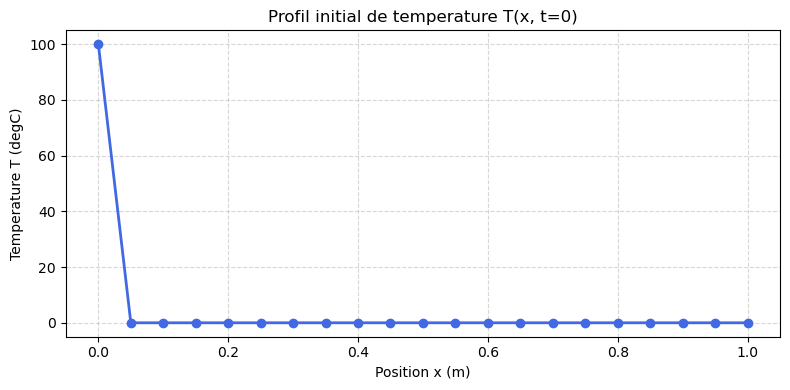

In [221]:
# --- Creation de la grille spatiale ---
x = np.linspace(L,0,N+1)  # N+1 points de x=0 a x=L

# --- Condition initiale ---
T = np.ones(N + 1) * T_init

# --- Application des conditions aux limites ---
T[0] = T_droite
T[-1] =T_gauche

# --- Visualisation du profil initial ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, T, 'o-', color='royalblue', linewidth=2, markersize=6)
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Temperature T (degC)')
ax.set_title("Profil initial de temperature T(x, t=0)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


## Boucle Temporelle Principale

In [222]:
# --- Stockage periodique de la solution ---
save_frac = 10
save_step = max(1, nt // save_frac)
T_save = [T.copy()]
t_save = [0.0]

T_new = T.copy()

for n in range(1, nt+1):
    # Mise a jour des noeuds interieurs (i = 1 a N-1)
    for i in range(1, N):
        T_new[i] = T_new[i] + r*(T_new[i+1] - 2*T_new[i] + T_new[i-1])

    T = T_new.copy()  # pourquoi " copy " ?

    # Sauvegarde periodique
    if n % save_step == 0:
        T_save.append(T.copy())
        
T_save = np . array ( T_save )
print ( f" Nombre de profils sauvegardes : {len ( T_save )}")


 Nombre de profils sauvegardes : 11


# Analyse d’un cas minimaliste

In [223]:
"""
import numpy as np

T = np . array ([1.0 , 2.0 , 3.0])
T_save = []

T_save . append ( T ) # stocke la référence
print ( T_save [0]) # [1. 2. 3.]

T [0] = 999 # on modifie T
print ( T_save [0]) # [999. 2. 3.] modifié aussi !

T_save . append ( T . copy () ) # stocke une copie indépendante
T [0] = 999
print ( T_save [0]) # [1. 2. 3.] inchangé
"""

'\nimport numpy as np\n\nT = np . array ([1.0 , 2.0 , 3.0])\nT_save = []\n\nT_save . append ( T ) # stocke la référence\nprint ( T_save [0]) # [1. 2. 3.]\n\nT [0] = 999 # on modifie T\nprint ( T_save [0]) # [999. 2. 3.] modifié aussi !\n\nT_save . append ( T . copy () ) # stocke une copie indépendante\nT [0] = 999\nprint ( T_save [0]) # [1. 2. 3.] inchangé\n'

## Visualisation des Résultats

/tmp/ipykernel_3872/2387787247.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


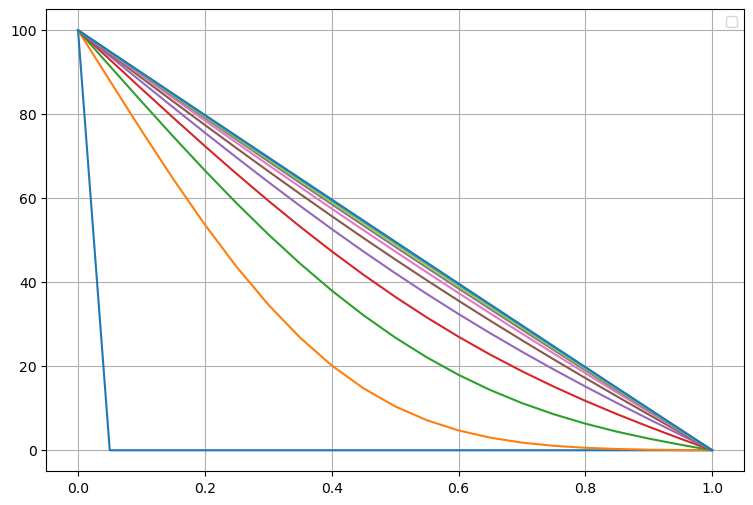

In [224]:
fig , ax = plt . subplots ( figsize =(9 , 6) )

colors = cm . plasma ( np . linspace (0 , 1 , len ( T_save ) ) )
for i in range(len(T_save)):
    ax.plot(x,T_save[i])
    
plt.grid()
plt.legend()
plt.show()